# LLM Results Visualization

This notebook visualizes the current LLM simplification results for thesis reporting and appendix material.

It is built around the local evaluation pipeline and works with the pilot outputs already present in the repository. If you later run a full LLM batch, you can point the path variables in the next cell to the new CSV files without changing the plotting code.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

OUTPUTS = ROOT / "outputs"
PATHS = {
    "ranking": OUTPUTS / "pilot_ranking_local" / "pilot_condition_ranked.csv",
    "experiments": OUTPUTS / "pilot_12text_experiments.csv",
    "text_metrics": OUTPUTS / "pilot_methodology_text_metrics.csv",
    "pairwise": OUTPUTS / "pilot_methodology_pairwise_comparisons.csv",
    "human_text_summary": OUTPUTS / "human_baseline_summaries" / "text_metric_summary.csv",
    "human_pairwise_summary": OUTPUTS / "human_baseline_summaries" / "pairwise_summary.csv",
}

for label, path in PATHS.items():
    print(f"{label:>20}: {'OK' if path.exists() else 'MISSING'}  {path}")

             ranking: OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\pilot_ranking_local\pilot_condition_ranked.csv
         experiments: OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\pilot_12text_experiments.csv
        text_metrics: OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\pilot_methodology_text_metrics.csv
            pairwise: OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\pilot_methodology_pairwise_comparisons.csv
  human_text_summary: OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\human_baseline_summaries\text_metric_summary.csv
human_pairwise_summary: OK  D:\Year-3-Uni\thesis\Code\LGP-score\outputs\human_baseline_summaries\pairwise_summary.csv


In [2]:
def require_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def parse_variant(value: str) -> dict[str, object]:
    parts = str(value).split("::")
    parsed = {
        "provider": parts[0] if len(parts) > 0 else None,
        "model": parts[1] if len(parts) > 1 else None,
        "strategy": parts[2] if len(parts) > 2 else None,
        "temperature": np.nan,
    }
    if len(parts) > 3:
        match = re.search(r"temp=([0-9.]+)", parts[3])
        if match:
            parsed["temperature"] = float(match.group(1))
    return parsed


ranking = require_csv(PATHS["ranking"])
experiments = require_csv(PATHS["experiments"])
text_metrics = require_csv(PATHS["text_metrics"])
pairwise = require_csv(PATHS["pairwise"])
human_text_summary = require_csv(PATHS["human_text_summary"])
human_pairwise_summary = require_csv(PATHS["human_pairwise_summary"])

llm_text_metrics = text_metrics[text_metrics["source_type"] == "llm_simplification"].copy()
llm_pairwise = pairwise[pairwise["comparison_type"] == "llm_simplification"].copy()

variant_parts = llm_text_metrics["variant"].map(parse_variant).apply(pd.Series)
llm_text_metrics = pd.concat([llm_text_metrics, variant_parts], axis=1)

variant_parts = llm_pairwise["variant"].map(parse_variant).apply(pd.Series)
llm_pairwise = pd.concat([llm_pairwise, variant_parts], axis=1)

human_benchmark = human_text_summary[
    (human_text_summary["source_type"] == "human_reference")
    & (human_text_summary["level"] == "Elementary")
].iloc[0]

ranking.head()

,provider,model,strategy,temperature,variant,rows,json_success_rate,fk_grade_mean,fk_grade_std,aoa,concreteness,imageability,fk_grade,mtld,cli,tier2_proxy_token_ratio,human_benchmark_distance,human_benchmark_score,semantic_similarity_sbert,delta_cli,delta_aoa,delta_concreteness,delta_imageability,delta_fk_grade,delta_mtld,delta_tier2_proxy_token_ratio,stability_score,overall_score
0,openai,openai/gpt-5.2,zero_shot,0.500,openai::openai/gpt-5.2::zero_shot::temp=0.5,12,1.000,6.611,1.218,319.030,366.843,394.276,6.611,98.890,0.146,0.058,0.209,0.827,0.910,0.480,-20.857,3.337,4.773,-3.316,-16.140,-0.021,0.451,0.797
1,openai,openai/gpt-5.2,few_shot,0.200,openai::openai/gpt-5.2::few_shot::temp=0.2,12,1.000,6.498,1.194,319.862,365.443,392.945,6.498,104.094,0.080,0.057,0.230,0.813,0.911,0.414,-20.025,1.937,3.442,-3.429,-10.936,-0.022,0.456,0.795
2,openai,openai/gpt-5.2,chain_of_thought,0.200,openai::openai/gpt-5.2::chain_of_thought::temp...,12,1.000,6.397,1.302,319.062,365.400,392.135,6.397,99.916,0.075,0.057,0.228,0.814,0.927,0.409,-20.825,1.895,2.632,-3.530,-15.114,-0.022,0.434,0.794
3,openai,openai/gpt-5.2,zero_shot,0.200,openai::openai/gpt-5.2::zero_shot::temp=0.2,12,1.000,6.543,1.240,316.963,364.607,391.544,6.543,101.516,0.081,0.053,0.254,0.797,0.914,0.415,-22.925,1.101,2.041,-3.384,-13.514,-0.025,0.446,0.789
4,openai,openai/gpt-5.2,zero_shot,0.000,openai::openai/gpt-5.2::zero_shot::temp=0.0,12,1.000,6.736,1.331,316.984,363.977,391.565,6.736,103.991,0.069,0.055,0.252,0.799,0.924,0.404,-22.904,0.472,2.062,-3.191,-11.039,-0.024,0.429,0.788


## Appendix Tables

The tables below are compact enough to export directly into an appendix if needed.

In [3]:
appendix_columns = [
    "strategy",
    "temperature",
    "json_success_rate",
    "fk_grade_mean",
    "fk_grade_std",
    "semantic_similarity_sbert",
    "human_benchmark_score",
    "overall_score",
]

appendix_table = ranking[appendix_columns].copy()
display(appendix_table)

human_table = human_text_summary[
    human_text_summary["variant"].isin(["human::advanced", "human::elementary"])
][[
    "variant",
    "aoa_mean",
    "concreteness_mean",
    "imageability_mean",
    "fk_grade_mean",
    "mtld_mean",
    "cli_mean",
    "tier2_proxy_token_ratio_mean",
]].copy()
display(human_table)

,strategy,temperature,json_success_rate,fk_grade_mean,fk_grade_std,semantic_similarity_sbert,human_benchmark_score,overall_score
0,zero_shot,0.500,1.000,6.611,1.218,0.910,0.827,0.797
1,few_shot,0.200,1.000,6.498,1.194,0.911,0.813,0.795
2,chain_of_thought,0.200,1.000,6.397,1.302,0.927,0.814,0.794
3,zero_shot,0.200,1.000,6.543,1.240,0.914,0.797,0.789
4,zero_shot,0.000,1.000,6.736,1.331,0.924,0.799,0.788
5,few_shot,0.000,1.000,6.678,1.452,0.916,0.819,0.786
6,few_shot,0.500,1.000,6.676,1.511,0.912,0.810,0.780
7,chain_of_thought,0.500,1.000,6.465,1.651,0.927,0.787,0.773
8,chain_of_thought,0.000,1.000,6.545,1.520,0.921,0.759,0.769


,variant,aoa_mean,concreteness_mean,imageability_mean,fk_grade_mean,mtld_mean,cli_mean,tier2_proxy_token_ratio_mean
0,human::advanced,359.450,355.626,383.006,11.131,110.285,-0.117,0.096
1,human::elementary,340.944,355.620,383.269,8.156,83.927,0.185,0.069


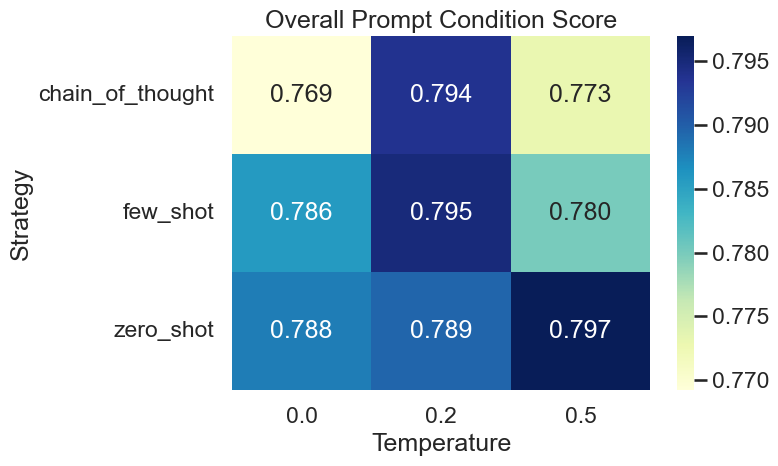

In [4]:
score_heatmap = ranking.pivot(index="strategy", columns="temperature", values="overall_score")
plt.figure(figsize=(8, 5))
sns.heatmap(score_heatmap, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Overall Prompt Condition Score")
plt.xlabel("Temperature")
plt.ylabel("Strategy")
plt.tight_layout()
plt.show()

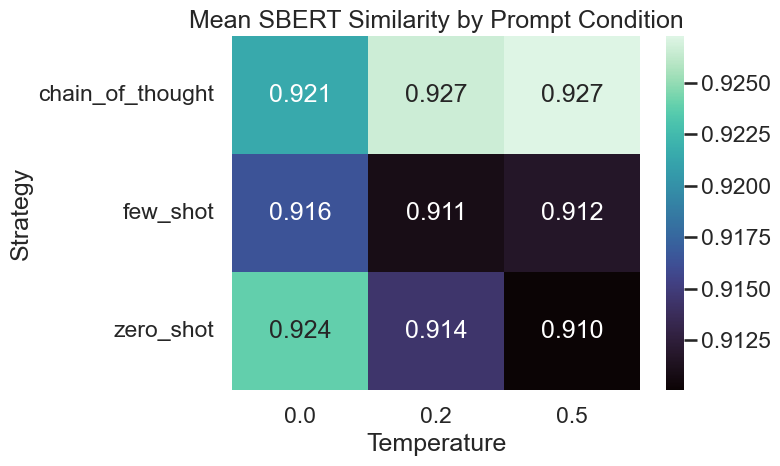

In [5]:
semantic_heatmap = ranking.pivot(index="strategy", columns="temperature", values="semantic_similarity_sbert")
plt.figure(figsize=(8, 5))
sns.heatmap(semantic_heatmap, annot=True, cmap="mako", fmt=".3f")
plt.title("Mean SBERT Similarity by Prompt Condition")
plt.xlabel("Temperature")
plt.ylabel("Strategy")
plt.tight_layout()
plt.show()

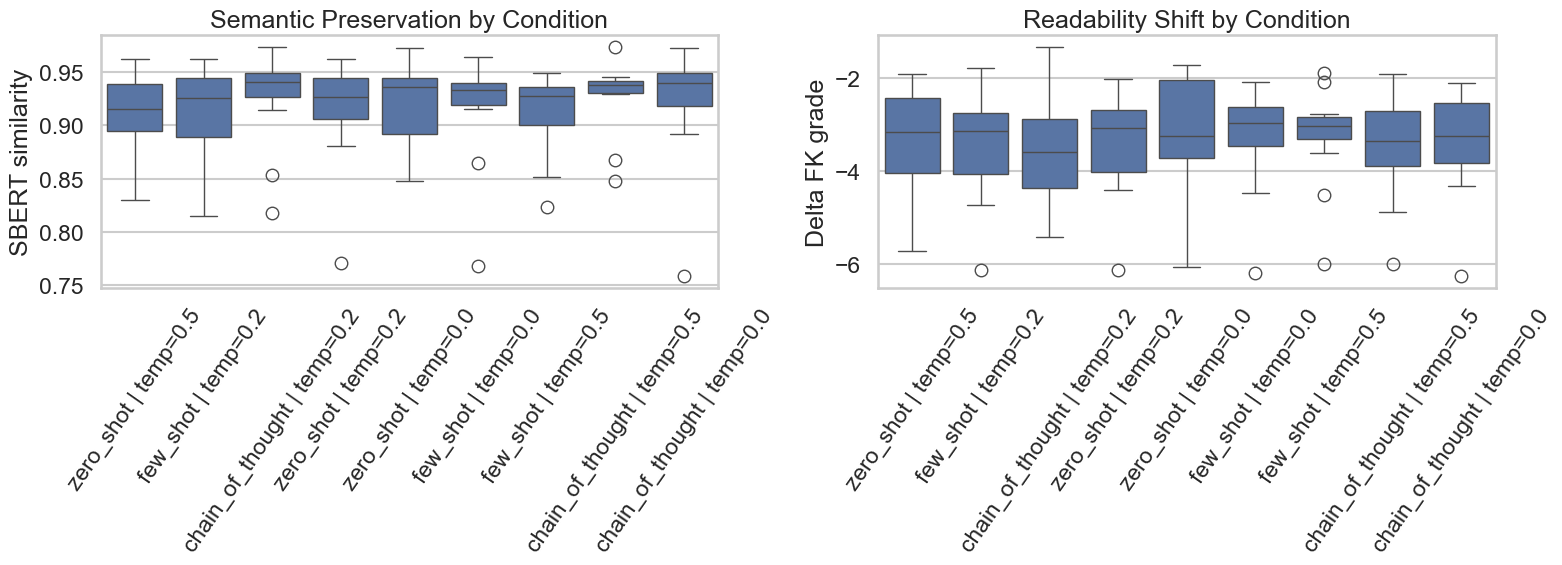

In [6]:
condition_order = ranking["variant"].tolist()

llm_pairwise_plot = llm_pairwise.copy()
llm_pairwise_plot["condition"] = (
    llm_pairwise_plot["strategy"] + " | temp=" + llm_pairwise_plot["temperature"].astype(str)
)
condition_labels = [
    f"{parse_variant(variant)['strategy']} | temp={parse_variant(variant)['temperature']}"
    for variant in condition_order
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
sns.boxplot(data=llm_pairwise_plot, x="condition", y="semantic_similarity_sbert", order=condition_labels, ax=axes[0])
axes[0].set_title("Semantic Preservation by Condition")
axes[0].set_xlabel("")
axes[0].set_ylabel("SBERT similarity")
axes[0].tick_params(axis="x", rotation=55)

sns.boxplot(data=llm_pairwise_plot, x="condition", y="delta_fk_grade", order=condition_labels, ax=axes[1])
axes[1].set_title("Readability Shift by Condition")
axes[1].set_xlabel("")
axes[1].set_ylabel("Delta FK grade")
axes[1].tick_params(axis="x", rotation=55)

plt.tight_layout()
plt.show()

,label,aoa,cli,tier2,fk
0,Human Advanced,359.450,-0.117,0.096,11.131
1,Human Elementary,340.944,0.185,0.069,8.156
2,zero_shot | 0.5,319.030,0.146,0.058,6.611
3,few_shot | 0.2,319.862,0.080,0.057,6.498
4,chain_of_thought | 0.2,319.062,0.075,0.057,6.397


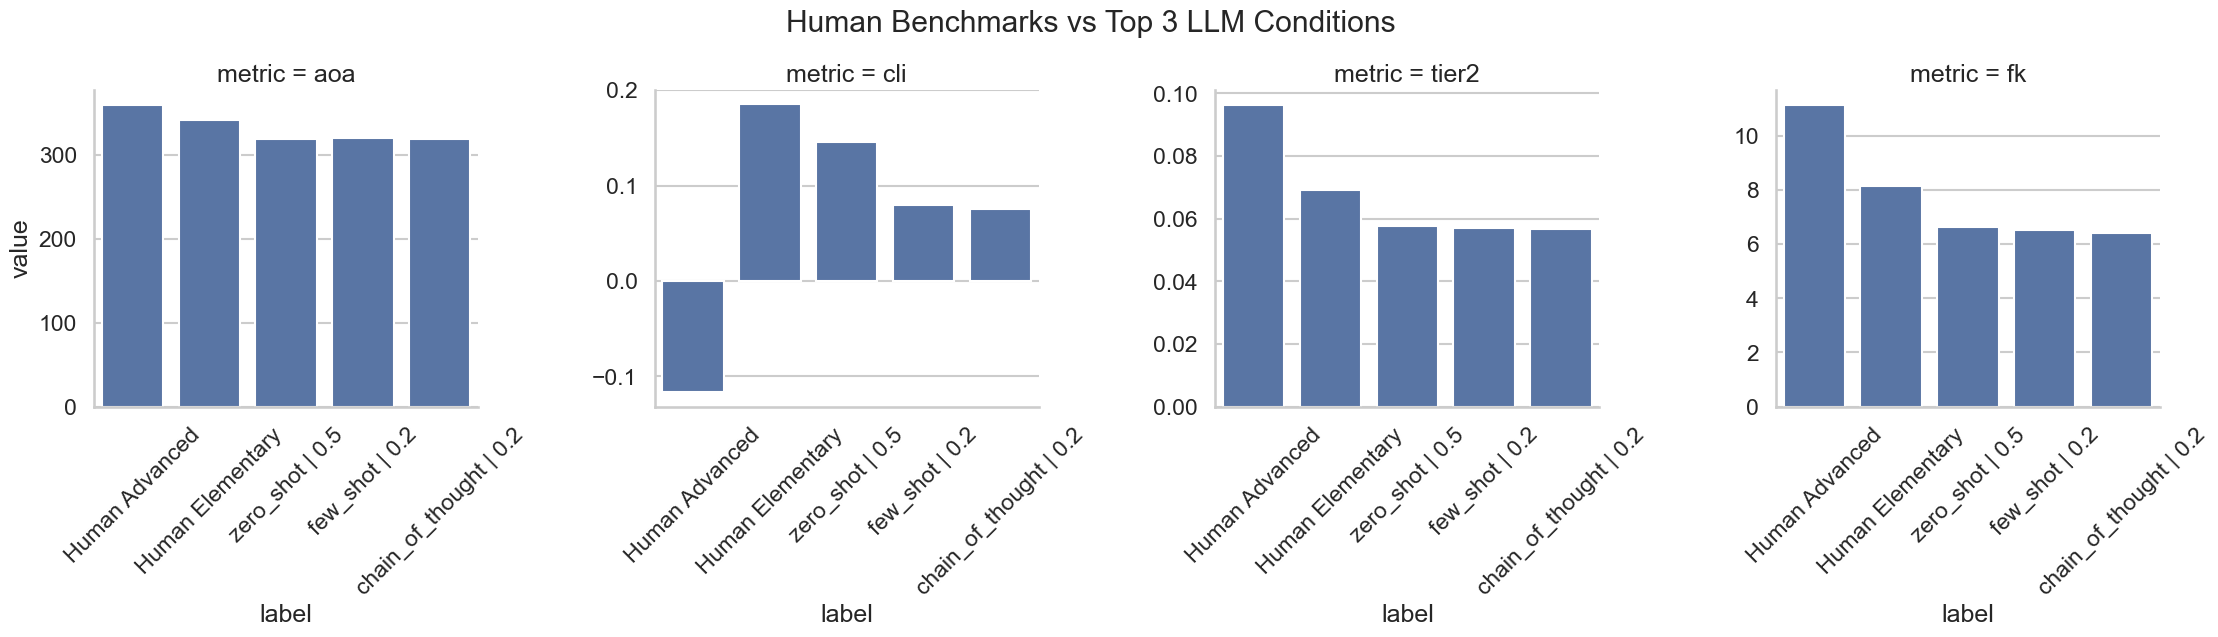

In [7]:
top_variants = ranking.head(3)["variant"].tolist()

comparison_rows = []
comparison_rows.append({
    "label": "Human Advanced",
    "aoa": human_text_summary.loc[human_text_summary['variant'] == 'human::advanced', 'aoa_mean'].iloc[0],
    "cli": human_text_summary.loc[human_text_summary['variant'] == 'human::advanced', 'cli_mean'].iloc[0],
    "tier2": human_text_summary.loc[human_text_summary['variant'] == 'human::advanced', 'tier2_proxy_token_ratio_mean'].iloc[0],
    "fk": human_text_summary.loc[human_text_summary['variant'] == 'human::advanced', 'fk_grade_mean'].iloc[0],
})
comparison_rows.append({
    "label": "Human Elementary",
    "aoa": human_text_summary.loc[human_text_summary['variant'] == 'human::elementary', 'aoa_mean'].iloc[0],
    "cli": human_text_summary.loc[human_text_summary['variant'] == 'human::elementary', 'cli_mean'].iloc[0],
    "tier2": human_text_summary.loc[human_text_summary['variant'] == 'human::elementary', 'tier2_proxy_token_ratio_mean'].iloc[0],
    "fk": human_text_summary.loc[human_text_summary['variant'] == 'human::elementary', 'fk_grade_mean'].iloc[0],
})

for variant in top_variants:
    row = llm_text_metrics[llm_text_metrics["variant"] == variant]
    parsed = parse_variant(variant)
    comparison_rows.append({
        "label": f"{parsed['strategy']} | {parsed['temperature']}",
        "aoa": row["aoa"].mean(),
        "cli": row["cli"].mean(),
        "tier2": row["tier2_proxy_token_ratio"].mean(),
        "fk": row["fk_grade"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

melted = comparison_df.melt(id_vars="label", var_name="metric", value_name="value")
g = sns.catplot(
    data=melted,
    kind="bar",
    x="label",
    y="value",
    col="metric",
    sharey=False,
    height=5,
    aspect=1.1,
)
g.set_xticklabels(rotation=45)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Human Benchmarks vs Top 3 LLM Conditions")
plt.show()

In [8]:
export_dir = OUTPUTS / "appendix_tables"
export_dir.mkdir(parents=True, exist_ok=True)

appendix_table.to_csv(export_dir / "llm_condition_overview.csv", index=False)
comparison_df.to_csv(export_dir / "top_conditions_vs_human_benchmark.csv", index=False)
human_table.to_csv(export_dir / "human_benchmark_overview.csv", index=False)

print(f"Saved appendix tables to: {export_dir}")

Saved appendix tables to: D:\Year-3-Uni\thesis\Code\LGP-score\outputs\appendix_tables


## Run 2 Prompt Pilot

The original notebook visuals are based on the first pilot run. This section adds a separate view for the second run and a direct first-vs-second comparison.


In [9]:
run1_ranked = pd.read_csv(OUTPUTS / 'pilot_ranking_local' / 'pilot_condition_ranked.csv')
run2_ranked = pd.read_csv(OUTPUTS / 'pilot_ranking_run2' / 'pilot_condition_ranked.csv')
run_compare = pd.read_csv(OUTPUTS / 'pilot_run_comparison.csv')
run2_top = run2_ranked[['strategy','temperature','overall_score','semantic_similarity_sbert','human_benchmark_score','fk_grade_std']].copy().head(5)
display(run2_top.round(3))


,strategy,temperature,overall_score,semantic_similarity_sbert,human_benchmark_score,fk_grade_std
0,zero_shot,0.200,0.798,0.916,0.831,1.248
1,zero_shot,0.000,0.797,0.913,0.808,1.140
2,few_shot,0.500,0.792,0.917,0.810,1.258
3,zero_shot,0.500,0.785,0.905,0.818,1.402
4,few_shot,0.200,0.784,0.914,0.810,1.427


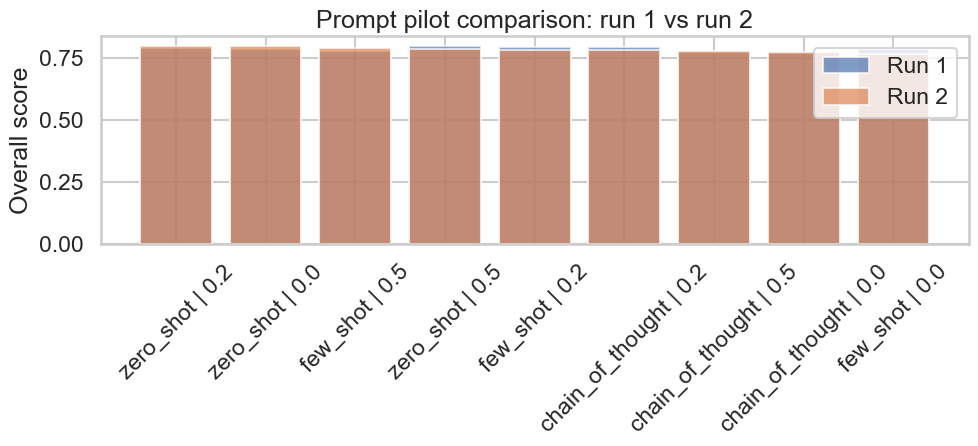

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = run_compare.copy()
plot_df['label'] = plot_df['strategy'] + ' | ' + plot_df['temperature'].astype(str)
ax.bar(plot_df['label'], plot_df['overall_score_run1'], alpha=0.7, label='Run 1')
ax.bar(plot_df['label'], plot_df['overall_score_run2'], alpha=0.7, label='Run 2')
ax.set_ylabel('Overall score')
ax.set_title('Prompt pilot comparison: run 1 vs run 2')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


## Aggregate Across Runs 2-4

This section summarizes the final repeated-run selection based on the mean overall score across the three sourced-prompt runs.


In [11]:
aggregate_ranked = pd.read_csv(OUTPUTS / 'pilot_ranking_aggregate_runs2to4.csv')
display(aggregate_ranked[['final_rank','strategy','temperature','mean_overall_score','std_overall_score','mean_json_success_rate','mean_semantic_similarity_sbert','mean_human_benchmark_score']].head(5).round(3))


,final_rank,strategy,temperature,mean_overall_score,std_overall_score,mean_json_success_rate,mean_semantic_similarity_sbert,mean_human_benchmark_score
0,1,few_shot,0.500,0.763,0.042,0.944,0.872,0.819
1,2,chain_of_thought,0.500,0.761,0.039,0.944,0.882,0.815
2,3,chain_of_thought,0.200,0.759,0.043,0.944,0.879,0.807
3,4,chain_of_thought,0.000,0.752,0.044,0.944,0.883,0.780
4,5,zero_shot,0.000,0.750,0.073,0.917,0.847,0.794


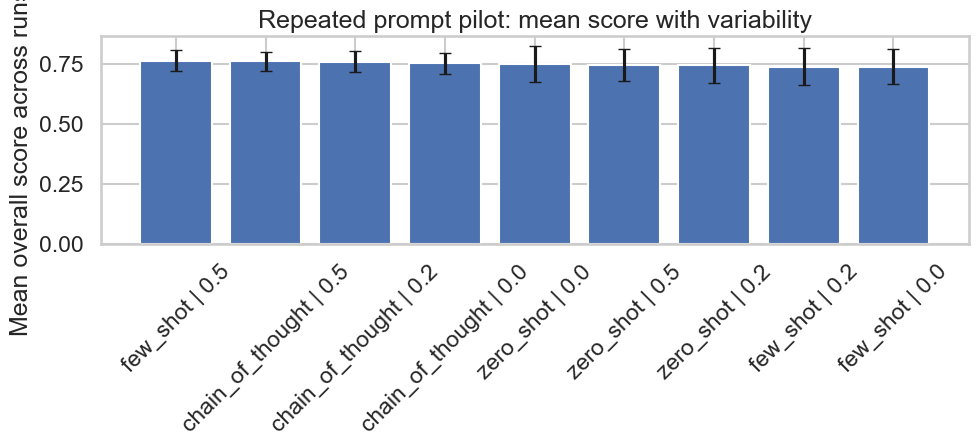

In [12]:
from matplotlib import pyplot as plt
agg = aggregate_ranked.sort_values('mean_overall_score', ascending=False).copy()
agg['label'] = agg['strategy'] + ' | ' + agg['temperature'].astype(str)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(agg['label'], agg['mean_overall_score'], yerr=agg['std_overall_score'], capsize=4)
ax.set_ylabel('Mean overall score across runs 2-4')
ax.set_title('Repeated prompt pilot: mean score with variability')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
